# 3. A sodium ionomer with and without smeared electrostatics

A precise polyethylene-acrylate ionomer (one `-CH2-CH(CH2COO-)-CH2-` block every
15 backbone carbons) with its Na+ counterions, initialized twice from the
same placement: with the default protocol (no charges during DPD), and with
FlowerMD's optional smeared Coulomb term, where each charge is a Gaussian
cloud so opposite charges can pass through each other without diverging.

The counterions are placed on lattice sites like every other unit, not next
to the carboxylates, so any pairing comes from the interactions. We compare
the ion aggregates (Na+ linked to carboxylates within 3 Å) right after
initialization and after the Sage minimization that follows.

The paper-scale version of this comparison (200 chains, 71,800 atoms, three
seeds, two smearing widths) is the experiment
`electrostatics-during-initialization__smeared-charges-on-sodium-ionomer`.
This notebook uses 40 chains; it runs in minutes on a GPU.

In [1]:
import hoomd

# GPU if one is visible, otherwise CPU. OpenMM follows the same choice.
try:
    DEVICE = hoomd.device.GPU()
    OPENMM_PLATFORM = "CUDA"
except Exception:
    DEVICE = hoomd.device.CPU()
    OPENMM_PLATFORM = "CPU"
print(DEVICE, OPENMM_PLATFORM)

<hoomd.device.GPU object at 0x14d0708a5760> CUDA


In [2]:
# The frozen all-atom PhantomWalk protocol, written out explicitly.
PROTOCOL = dict(
    bonded="uff", A=1250.0, gamma=200.0, kT=1.0, r_cut=3.5, bonded_scale=30.0,
    epsilon_weighting=True, protect_stereochemistry=True, stereo_k=30000.0,
)
RUN = dict(
    dpd_min_steps=3500, dpd_chunk=500, dpd_max_steps=40000, energy_tol=0.02,
    consecutive=2, dpd_samples_per_chunk=5, fire_steps=100, fire_dt=0.001,
    require_convergence=False,
)
DT = 0.001

In [3]:
import mbuild as mb
import numpy as np
import unyt as u
from flowermd.library import AllAtomDPD, AllAtomLattice, AllAtomPhantomWalk, PEAAIonomer
from phantomwalk.all_atom import ion_sites, ion_structure, sage_handoff

chains = PEAAIonomer(lengths=7, num_mols=40, pattern="EEAEE", tacticity="atactic", seed=5)
sodium = chains.counterions("[Na+]")
system = AllAtomLattice([chains, sodium], density=0.85 * u.g / u.cm**3, unit="repeat", seed=5)
ions, carboxylates = ion_sites(system.system, counterion="Na")
print(f"{system.system.n_particles} atoms, {len(ions)} Na+, {len(carboxylates)} carboxylates")

2026-09-23 15:46:16,816 - mbuild.compound - WARNING - Compound.box.lengths < Compound.boundingbox.lengths. There may be particles outside of the defined simulation box.
14360 atoms, 280 Na+, 280 carboxylates


In [4]:
ELECTROSTATICS = {
    "coulomb off": dict(),
    "smeared coulomb": dict(charges="nagl", electrostatics="smeared",
                            charge_smearing=2.0, charge_scale=1.0, pppm_order=5),
}
CUTOFF_A = 3.0
results = {}
for label, extra in ELECTROSTATICS.items():
    ff = AllAtomDPD(system.system, **PROTOCOL, **extra)
    box_a = np.asarray(ff.frame.configuration.box[:3])
    sim = AllAtomPhantomWalk.from_system(system, forcefield=ff, dt=DT, device=DEVICE, seed=5)
    record = sim.run_initialization(**RUN)
    initialized = ion_structure(sim.final_positions() * 10, box_a, ions, carboxylates, CUTOFF_A)
    # to_compound() writes into the compound it is given; a clone keeps the
    # shared placement untouched for the next condition
    handoff, minimized_a = sage_handoff(sim.to_compound(mb.clone(system.system)), box_a / 10,
                                        platform=OPENMM_PLATFORM)
    minimized = ion_structure(minimized_a, box_a, ions, carboxylates, CUTOFF_A)
    results[label] = dict(record=record, initialized=initialized, minimized=minimized,
                          handoff=handoff)
    print(f"{label}: DPD {record['dpd_steps']} steps in {record['timings_s']['dpd']:.0f} s, "
          f"energy removed {handoff['energy_removed_sage_epsilon_atom']:.2f} eps_max/atom")

Initializing simulation state from a gsd.hoomd.Frame.
Step 5500 of 40000; TPS: 0.0; ETA: nan hours, nan minutes
Step 11000 of 40000; TPS: 0.0; ETA: nan hours, nan minutes
coulomb off: DPD 15000 steps in 22 s, energy removed 56.75 eps_max/atom
Initializing simulation state from a gsd.hoomd.Frame.
notice(2): charge.pppm: RMS error: 0.00271995
Step 5500 of 40000; TPS: 0.0; ETA: nan hours, nan minutes
Step 11000 of 40000; TPS: 0.0; ETA: nan hours, nan minutes
Step 16500 of 40000; TPS: 0.0; ETA: nan hours, nan minutes
Step 22000 of 40000; TPS: 0.0; ETA: nan hours, nan minutes
notice(2): charge.pppm: RMS error: 0.00271995
smeared coulomb: DPD 23000 steps in 55 s, energy removed 17.58 eps_max/atom


In [5]:
print(f"{'':>16} {'stage':>11} {'free Na+':>9} {'aggregates':>11} {'largest':>8} {'ion-weighted mean':>18}")
for label, r in results.items():
    for stage in ("initialized", "minimized"):
        s = r[stage]
        print(f"{label:>16} {stage:>11} {s['free_ion_fraction']:9.2f} {s['n_aggregates']:11d} "
              f"{s['largest_aggregate']:8d} {s['ion_weighted_mean_size']:18.2f}")

                       stage  free Na+  aggregates  largest  ion-weighted mean
     coulomb off initialized      0.85         272        3               1.06
     coulomb off   minimized      0.01          52       47              13.98
 smeared coulomb initialized      0.72         272        2               1.06
 smeared coulomb   minimized      0.00          51       49              16.05


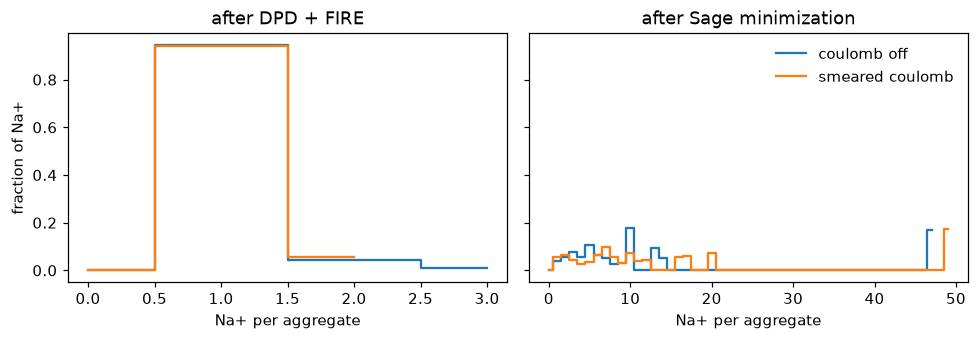

In [6]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
    for ax, stage in zip(axes, ("initialized", "minimized")):
        for label, r in results.items():
            frac = np.asarray(r[stage]["ion_fraction_by_size"])
            ax.step(np.arange(len(frac)), frac, where="mid", label=label)
        ax.set_xlabel("Na+ per aggregate")
        ax.set_title(f"after {stage.replace('initialized', 'DPD + FIRE').replace('minimized', 'Sage minimization')}")
    axes[0].set_ylabel("fraction of Na+")
    axes[1].legend(frameon=False)
    fig.tight_layout()

Which aggregate distribution is *right* needs an equilibrated reference (long
MD at high temperature); what this shows is that the initializer's choice of
interactions changes the ion structure a user starts from, at the cost of one
PPPM term during DPD.